# ResNet50 (View-Independent) Image Preprocessing Pipelines Experiments

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.applications import ResNet50
import cv2
import sys
import time
import os

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 311, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 311 (delta 35), reused 33 (delta 11), pack-reused 222 (from 1)
Receiving objects: 100% (311/311), 9.78 MiB | 13.39 MiB/s, done.
Resolving deltas: 100% (140/140), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessing_pipelines import *
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.view_independent.dataset import generate_dataset
from src.models.view_independent.resnet50CNN import create_resnet50_model
from src.models.model_functions import compile_model
from src.visualizations import *

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training, validation and testing datasets (containing images)
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/test_dataset.zip" -d "/content/extracted_test_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training, validation and testing metadata from csv files and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")
test_df = pd.read_csv(dataset_root + "/test_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)
test_df['new_image_path'] = test_df['image_path'].apply(update_image_path_testing)

In [ ]:
# Label encoding all dataframes
train_df['pathology'] = train_df['pathology'].map({'BENIGN': 0.0, 'MALIGNANT': 1.0})
val_df['pathology'] = val_df['pathology'].map({'BENIGN': 0.0, 'MALIGNANT': 1.0})
test_df['pathology'] = test_df['pathology'].map({'BENIGN': 0.0, 'MALIGNANT': 1.0})

In [ ]:
# Print pathology distribution in each set
print(train_df['pathology'].value_counts())
print(val_df['pathology'].value_counts())
print(test_df['pathology'].value_counts())

pathology
0.0    1371
1.0     904
Name: count, dtype: int64
pathology
0.0    357
1.0    230
Name: count, dtype: int64
pathology
0.0    382
1.0    322
Name: count, dtype: int64


In [ ]:
# No. of testing image samples
testing_images_count = len(test_df)

# True pathology labels
true_pathology = test_df['pathology']

# Convert true pathology series to numpy array
true_pathology_np = true_pathology.to_numpy()

In [ ]:
# CSV Files to store all experimental results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Experiment_Results/image_preprocessing_results.csv"

## P0 Image Preprocessing Pipeline Experiment

**Baseline Image Preprocessing Pipeline**

* Resizing
* Normalization

In [ ]:
# Select the p0 image preprocessor function from the image preprocessor dictionary
p0 = IMAGE_PREPROCESSORS['P0']

In [ ]:
# Create a tf.data dataset with p0 image preprocessing
train_dataset_p0 = generate_dataset(train_df, 32, p0, 'resnet50', training=True)
val_dataset_p0 = generate_dataset(val_df, 32, p0, 'resnet50', training=False)
test_dataset_p0 = generate_dataset(test_df, 32, p0, 'resnet50', training=False)

In [ ]:
# Create a Resnet50 model for p0 pipeline
resnet50_p0 = create_resnet50_model()
resnet50_p0 = compile_model(resnet50_p0)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
# Train Resnet50 with training dataset for p0 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p0
train_start_p0 = time.time()

# Resnet50 with p0 training for 20 epochs
resnet50_p0.fit(train_dataset_p0, validation_data=val_dataset_p0, epochs=20)

# Memory used in p0
peak_memory_p0 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p0
train_end_p0 = time.time()

# Total training time for p0 in minutes
training_time_p0 = (train_end_p0 - train_start_p0)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 66s 245ms/step - accuracy: 0.6040 - auc: 0.6236 - loss: 0.6834 - precision: 0.5020 - recall: 0.4181 - val_accuracy: 0.6797 - val_auc: 0.7188 - val_loss: 0.5853 - val_precision: 0.6071 - val_recall: 0.5174
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 50s 196ms/step - accuracy: 0.6510 - auc: 0.7017 - loss: 0.6065 - precision: 0.5726 - recall: 0.4801 - val_accuracy: 0.7104 - val_auc: 0.7340 - val_loss: 0.5749 - val_precision: 0.6807 - val_recall: 0.4913
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 208ms/step - accuracy: 0.6782 - auc: 0.7433 - loss: 0.5735 - precision: 0.6144 - recall: 0.5111 - val_accuracy: 0.6951 - val_auc: 0.7533 - val_loss: 0.5613 - val_precision: 0.6220 - val_recall: 0.5652
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 50s 197ms/step - accuracy: 0.6809 - auc: 0.7381 - loss: 0.5783 - precision: 0.6138 - recall: 0.5310 - val_accuracy: 0.6951 - val_auc: 0.7497 - val_loss: 0.5754 - val_precision: 0.7429 - val_recall: 0.3391
Epoch 5/20
72/72 ━━━━━━━━━━━

### P0 Image Preprocessing Predictions

In [ ]:
# Predict Resnet50's prediction probabilities using test data for p0

# Prediction start time
predict_start_p0 = time.time()

# VGG16 with p0 predictions
prediction_probs_p0 = resnet50_p0.predict(test_dataset_p0)

# Prediction end time
predict_end_p0 = time.time()

# Total prediction time for p0 in seconds
prediction_time_p0 = predict_end_p0 - predict_start_p0

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 242ms/step


In [ ]:
# Evaluation metrics for Resnet50 with p0
eval_metrics_p0 = resnet50_p0.evaluate(test_dataset_p0, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.6449 - auc: 0.7393 - loss: 0.6393 - precision: 0.7571 - recall: 0.3292


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p0 = np.where(prediction_probs_p0 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p0 true and predicted values
tn_p0, fp_p0, fn_p0, tp_p0 = confusion_matrix(true_pathology, predictions_p0).ravel()

# Compute specificity using CM
specificity_p0 = tn_p0 / (tn_p0 + fp_p0)

# Compute F1 Score using recall and precision
f1_score_p0 = 0.0
if eval_metrics_p0['precision'] + eval_metrics_p0['recall'] != 0.0:
  f1_score_p0 = (2 * eval_metrics_p0['precision'] * eval_metrics_p0['recall']) / (eval_metrics_p0['precision'] + eval_metrics_p0['recall'])

# Parameters of Resnet50 View-Independent model
resnet50_params_p0 = resnet50_p0.count_params()

In [ ]:
# Generate a results dataframe for results of p0 experiment
results_p0 = generate_results_df('ResNet50', 'View_Independent', 'P0', eval_metrics_p0, specificity_p0, f1_score_p0, training_time_p0, prediction_time_p0, peak_memory_p0, resnet50_params_p0)

# Store p0 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p0)

Stored results for 0    P0
Name: image_preprocessing_pipeline, dtype: object pipeline


### P0 Image Preprocessing Graphs

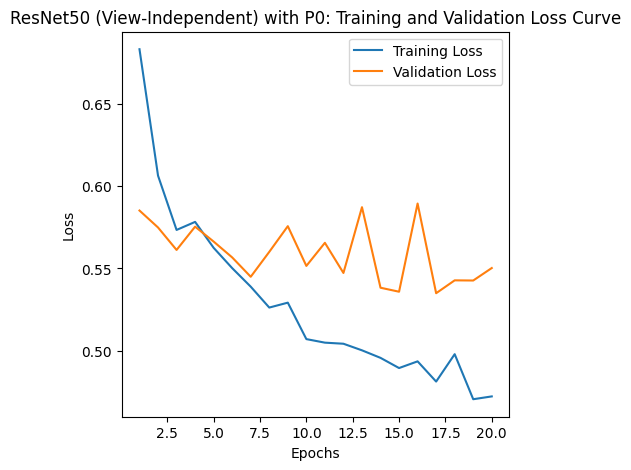

In [ ]:
# Training-Validation Loss curve for P0 pipeline
plot_training_validation_loss(resnet50_p0.history, 'ResNet50 (View-Independent)', 'P0')

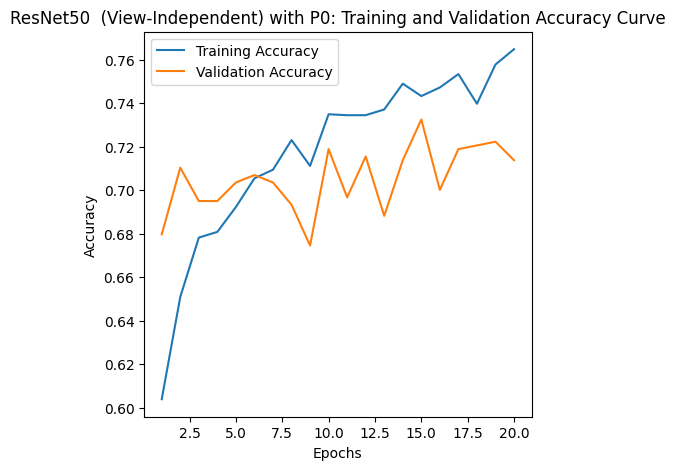

In [ ]:
# Training-Validation Accuracy curve for P0 pipeline
plot_training_validation_accuracy(resnet50_p0.history, 'ResNet50  (View-Independent)', 'P0')

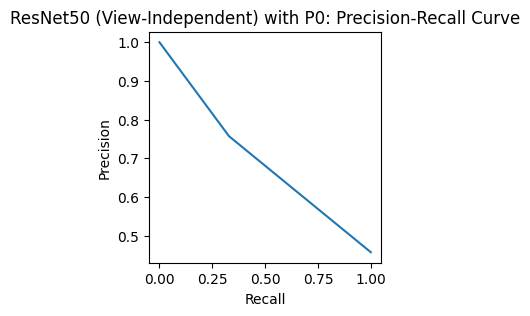

In [ ]:
# Precision-Recall curve for P0 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p0, 'ResNet50 (View-Independent)', 'P0')

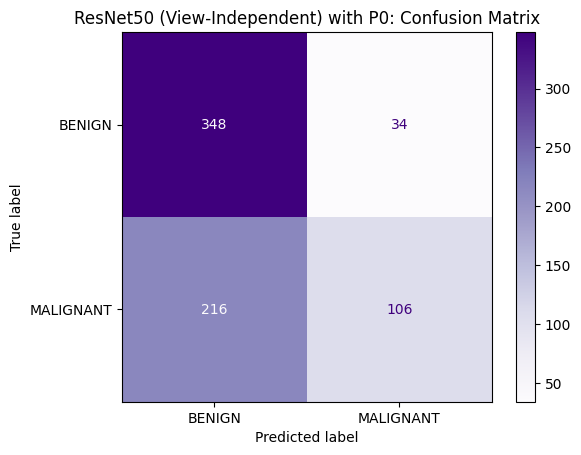

In [ ]:
# Confusion matrix for P0 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p0, 'ResNet50 (View-Independent)', 'P0')

## P1 Image Preprocessing Pipeline Experiment

* Resizing
* Grayscaling
* Normalization

In [ ]:
# Select the p1 image preprocessor function from the image preprocessor dictionary
p1 = IMAGE_PREPROCESSORS['P1']

In [ ]:
# Create a tf.data dataset with p1 image preprocessing
train_dataset_p1 = generate_dataset(train_df, 32, p1, 'resnet50', training=True)
val_dataset_p1 = generate_dataset(val_df, 32, p1, 'resnet50', training=False)
test_dataset_p1 = generate_dataset(test_df, 32, p1, 'resnet50', training=False)

In [ ]:
# Create a Resnet50 model for p1 pipeline
resnet50_p1 = create_resnet50_model()
resnet50_p1 = compile_model(resnet50_p1)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Train Resnet50 with training dataset for p1 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p1
train_start_p1 = time.time()

# Resnet50 with p1 training for 20 epochs
resnet50_p1.fit(train_dataset_p1, validation_data=val_dataset_p1, epochs=20)

# Memory used in p1
peak_memory_p1 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p1
train_end_p1 = time.time()

# Total training time for p1 in minutes
training_time_p1 = (train_end_p1 - train_start_p1)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 64s 223ms/step - accuracy: 0.6040 - auc: 0.6236 - loss: 0.6834 - precision: 0.5020 - recall: 0.4181 - val_accuracy: 0.6797 - val_auc: 0.7188 - val_loss: 0.5853 - val_precision: 0.6071 - val_recall: 0.5174
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 48s 177ms/step - accuracy: 0.6510 - auc: 0.7017 - loss: 0.6065 - precision: 0.5726 - recall: 0.4801 - val_accuracy: 0.7104 - val_auc: 0.7340 - val_loss: 0.5749 - val_precision: 0.6807 - val_recall: 0.4913
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 50s 186ms/step - accuracy: 0.6782 - auc: 0.7433 - loss: 0.5735 - precision: 0.6144 - recall: 0.5111 - val_accuracy: 0.6951 - val_auc: 0.7533 - val_loss: 0.5613 - val_precision: 0.6220 - val_recall: 0.5652
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 48s 178ms/step - accuracy: 0.6809 - auc: 0.7381 - loss: 0.5783 - precision: 0.6138 - recall: 0.5310 - val_accuracy: 0.6951 - val_auc: 0.7497 - val_loss: 0.5754 - val_precision: 0.7429 - val_recall: 0.3391
Epoch 5/20
72/72 ━━━━━━━━━━━

### P1 Image Preprocessing Predictions

In [ ]:
# Predict Resnet50's prediction probabilities using test data for p1

# Prediction start time
predict_start_p1 = time.time()

# Resnet50 with p1 predictions
prediction_probs_p1 = resnet50_p1.predict(test_dataset_p1)

# Prediction end time
predict_end_p1 = time.time()

# Total prediction time for p1 in seconds
prediction_time_p1 = predict_end_p1 - predict_start_p1

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step


In [ ]:
# Evaluation metrics for Resnet50 with p1
eval_metrics_p1 = resnet50_p1.evaluate(test_dataset_p1, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.6449 - auc: 0.7393 - loss: 0.6393 - precision: 0.7571 - recall: 0.3292


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p1 = np.where(prediction_probs_p1 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p1 true and predicted values
tn_p1, fp_p1, fn_p1, tp_p1 = confusion_matrix(true_pathology, predictions_p1).ravel()

# Compute specificity using CM
specificity_p1 = tn_p1 / (tn_p1 + fp_p1)

# Compute F1 Score using recall and precision
f1_score_p1 = 0.0
if eval_metrics_p1['precision'] + eval_metrics_p1['recall'] != 0.0:
  f1_score_p1 = (2 * eval_metrics_p1['precision'] * eval_metrics_p1['recall']) / (eval_metrics_p1['precision'] + eval_metrics_p1['recall'])

# Parameters of Resnet50 View-Independent model
resnet50_params_p1 = resnet50_p1.count_params()

In [ ]:
# Generate a results dataframe for results of p1 experiment
results_p1 = generate_results_df('ResNet50', 'View_Independent', 'P1', eval_metrics_p1, specificity_p1, f1_score_p1, training_time_p1, prediction_time_p1, peak_memory_p1, resnet50_params_p1)

# Store p1 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p1)

Stored results for 0    P1
Name: image_preprocessing_pipeline, dtype: object pipeline


### P1 Image Preprocessing Graphs

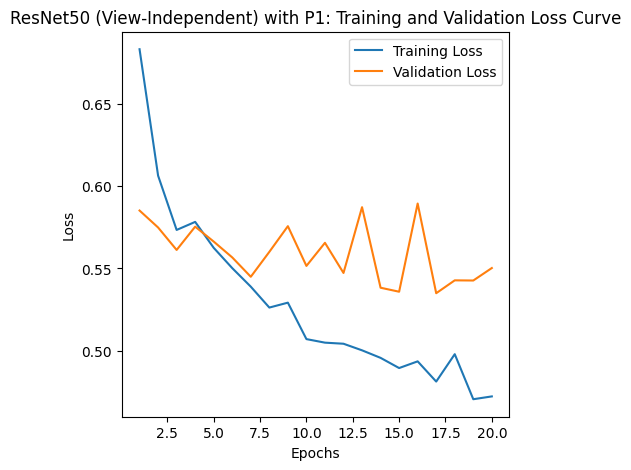

In [ ]:
# Training-Validation Loss curve for P1 pipeline
plot_training_validation_loss(resnet50_p1.history, 'ResNet50 (View-Independent)', 'P1')

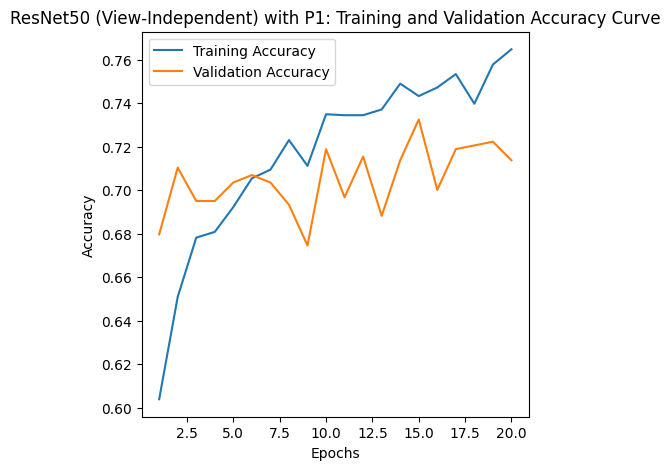

In [ ]:
# Training-Validation Accuracy curve for P1 pipeline
plot_training_validation_accuracy(resnet50_p1.history, 'ResNet50 (View-Independent)', 'P1')

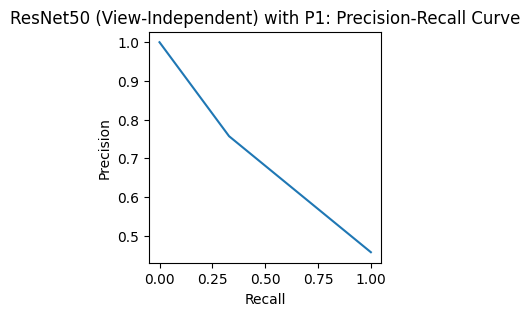

In [ ]:
# Precision-Recall curve for P1 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p1, 'ResNet50 (View-Independent)', 'P1')

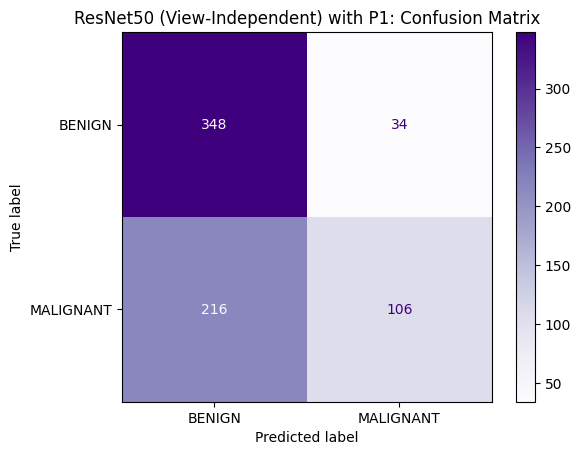

In [ ]:
# Confusion matrix for P1 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p1, 'ResNet50 (View-Independent)', 'P1')

## P2 Image Preprocessing Pipeline Experiment

* Resizing
* CLAHE
* Normalization

In [ ]:
# Select the p2 image preprocessor function from the image preprocessor dictionary
p2 = IMAGE_PREPROCESSORS['P2']

In [ ]:
# Create a tf.data dataset with p2 image preprocessing
train_dataset_p2 = generate_dataset(train_df, 32, p2, 'resnet50', training=True)
val_dataset_p2 = generate_dataset(val_df, 32, p2, 'resnet50', training=False)
test_dataset_p2 = generate_dataset(test_df, 32, p2, 'resnet50', training=False)

In [ ]:
# Create a Resnet50 model for p2 pipeline
resnet50_p2 = create_resnet50_model()
resnet50_p2 = compile_model(resnet50_p2)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train Resnet50 with training dataset for p2 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p2
train_start_p2 = time.time()

# Resnet50 with p2 training for 20 epochs
resnet50_p2.fit(train_dataset_p2, validation_data=val_dataset_p2, epochs=20)

# Memory used in p2
peak_memory_p2 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p2
train_end_p2 = time.time()

# Total training time for p2 in minutes
training_time_p2 = (train_end_p2 - train_start_p2)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 67s 235ms/step - accuracy: 0.6035 - auc: 0.6224 - loss: 0.6888 - precision: 0.5013 - recall: 0.4281 - val_accuracy: 0.6559 - val_auc: 0.7058 - val_loss: 0.5913 - val_precision: 0.5778 - val_recall: 0.4522
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 199ms/step - accuracy: 0.6453 - auc: 0.6973 - loss: 0.6109 - precision: 0.5642 - recall: 0.4712 - val_accuracy: 0.6712 - val_auc: 0.7297 - val_loss: 0.5751 - val_precision: 0.6022 - val_recall: 0.4739
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 51s 194ms/step - accuracy: 0.6862 - auc: 0.7438 - loss: 0.5737 - precision: 0.6212 - recall: 0.5387 - val_accuracy: 0.6848 - val_auc: 0.7464 - val_loss: 0.5637 - val_precision: 0.6077 - val_recall: 0.5522
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 198ms/step - accuracy: 0.6738 - auc: 0.7315 - loss: 0.5831 - precision: 0.6036 - recall: 0.5221 - val_accuracy: 0.6865 - val_auc: 0.7403 - val_loss: 0.5863 - val_precision: 0.7805 - val_recall: 0.2783
Epoch 5/20
72/72 ━━━━━━━━━━━

### P2 Image Preprocessing Predictions

In [ ]:
# Predict Resnet50's prediction probabilities using test data for p2

# Prediction start time
predict_start_p2 = time.time()

# Resnet50 with p2 predictions
prediction_probs_p2 = resnet50_p2.predict(test_dataset_p2)

# Prediction end time
predict_end_p2 = time.time()

# Total prediction time for p2 in seconds
prediction_time_p2 = predict_end_p2 - predict_start_p2

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 234ms/step


In [ ]:
# Evaluation metrics for Resnet50 with p2
eval_metrics_p2 = resnet50_p2.evaluate(test_dataset_p2, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 272ms/step - accuracy: 0.6349 - auc: 0.7482 - loss: 0.6412 - precision: 0.7559 - recall: 0.2981


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p2 = np.where(prediction_probs_p2 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p2 true and predicted values
tn_p2, fp_p2, fn_p2, tp_p2 = confusion_matrix(true_pathology, predictions_p2).ravel()

# Compute specificity using CM
specificity_p2 = tn_p2 / (tn_p2 + fp_p2)

# Compute F1 Score using recall and precision
f1_score_p2 = 0.0
if eval_metrics_p2['precision'] + eval_metrics_p2['recall'] != 0.0:
  f1_score_p2 = (2 * eval_metrics_p2['precision'] * eval_metrics_p2['recall']) / (eval_metrics_p2['precision'] + eval_metrics_p2['recall'])

# Parameters of Resnet50 View-Independent model
resnet50_params_p2 = resnet50_p2.count_params()

In [ ]:
# Generate a results dataframe for results of p2 experiment
results_p2 = generate_results_df('ResNet50', 'View_Independent', 'P2', eval_metrics_p2, specificity_p2, f1_score_p2, training_time_p2, prediction_time_p2, peak_memory_p2, resnet50_params_p2)

# Store p2 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p2)

Stored results for 0    P2
Name: image_preprocessing_pipeline, dtype: object pipeline


### P2 Image Preprocessing Graphs

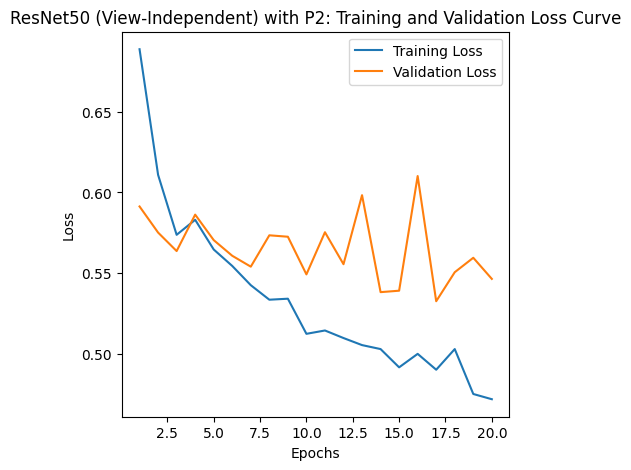

In [ ]:
# Training-Validation Loss curve for P2 pipeline
plot_training_validation_loss(resnet50_p2.history, 'ResNet50 (View-Independent)', 'P2')

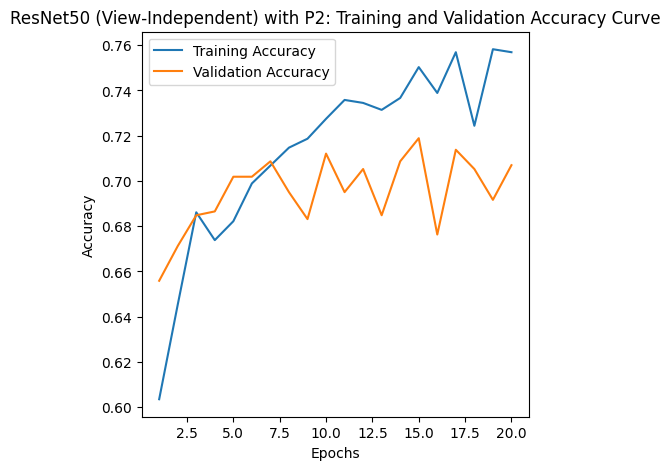

In [ ]:
# Training-Validation Accuracy curve for P2 pipeline
plot_training_validation_accuracy(resnet50_p2.history, 'ResNet50 (View-Independent)', 'P2')

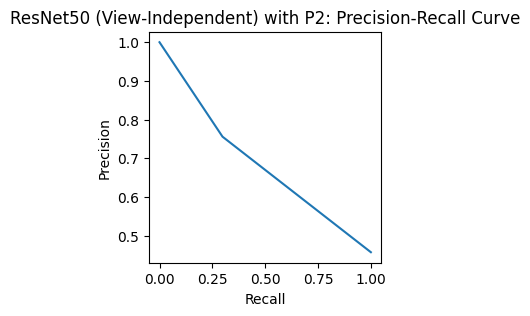

In [ ]:
# Precision-Recall curve for P2 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p2, 'ResNet50 (View-Independent)', 'P2')

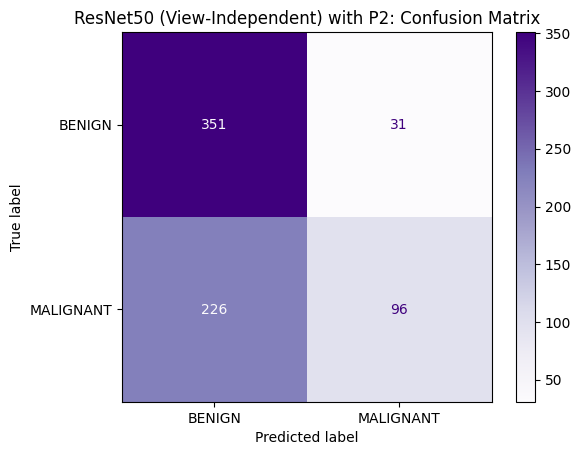

In [ ]:
# Confusion matrix for P2 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p2, 'ResNet50 (View-Independent)', 'P2')

## P3 Image Preprocessing Pipeline Experiment

* Resizing
* Gamma Correction
* Normalization

In [ ]:
# Select the p3 image preprocessor function from the image preprocessor dictionary
p3 = IMAGE_PREPROCESSORS['P3']

In [ ]:
# Create a tf.data dataset with p3 image preprocessing
train_dataset_p3 = generate_dataset(train_df, 32, p3, 'resnet50', training=True)
val_dataset_p3 = generate_dataset(val_df, 32, p3, 'resnet50', training=False)
test_dataset_p3 = generate_dataset(test_df, 32, p3, 'resnet50', training=False)

In [ ]:
# Create a Resnet50 model for p3 pipeline
resnet50_p3 = create_resnet50_model()
resnet50_p3 = compile_model(resnet50_p3)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Train Resnet50 with training dataset for p3 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p3
train_start_p3 = time.time()

# Resnet50 with p3 training for 20 epochs
resnet50_p3.fit(train_dataset_p3, validation_data=val_dataset_p3, epochs=20)

# Memory used in p3
peak_memory_p3 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p3
train_end_p3 = time.time()

# Total training time for p3 in minutes
training_time_p3 = (train_end_p3 - train_start_p3)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 66s 227ms/step - accuracy: 0.6110 - auc: 0.6225 - loss: 0.6675 - precision: 0.5134 - recall: 0.4015 - val_accuracy: 0.6491 - val_auc: 0.7005 - val_loss: 0.5920 - val_precision: 0.5845 - val_recall: 0.3609
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 189ms/step - accuracy: 0.6440 - auc: 0.6930 - loss: 0.6087 - precision: 0.5651 - recall: 0.4513 - val_accuracy: 0.6542 - val_auc: 0.7114 - val_loss: 0.5885 - val_precision: 0.6239 - val_recall: 0.2957
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 53s 201ms/step - accuracy: 0.6725 - auc: 0.7281 - loss: 0.5804 - precision: 0.6067 - recall: 0.5000 - val_accuracy: 0.6917 - val_auc: 0.7446 - val_loss: 0.5647 - val_precision: 0.6561 - val_recall: 0.4478
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 53s 213ms/step - accuracy: 0.6835 - auc: 0.7247 - loss: 0.5851 - precision: 0.6201 - recall: 0.5254 - val_accuracy: 0.6678 - val_auc: 0.7320 - val_loss: 0.5938 - val_precision: 0.7333 - val_recall: 0.2391
Epoch 5/20
72/72 ━━━━━━━━━━━

### P3 Image Preprocessing Predictions

In [ ]:
# Predict Resnet50's prediction probabilities using test data for p3

# Prediction start time
predict_start_p3 = time.time()

# Resnet50 with p3 predictions
prediction_probs_p3 = resnet50_p3.predict(test_dataset_p3)

# Prediction end time
predict_end_p3 = time.time()

# Total prediction time for p3 in seconds
prediction_time_p3 = predict_end_p3 - predict_start_p3

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 261ms/step


In [ ]:
# Evaluation metrics for Resnet50 with p3
eval_metrics_p3 = resnet50_p3.evaluate(test_dataset_p3, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 240ms/step - accuracy: 0.6293 - auc: 0.7403 - loss: 0.6665 - precision: 0.7521 - recall: 0.2826


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p3 = np.where(prediction_probs_p3 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p3 true and predicted values
tn_p3, fp_p3, fn_p3, tp_p3 = confusion_matrix(true_pathology, predictions_p3).ravel()

# Compute specificity using CM
specificity_p3 = tn_p3 / (tn_p3 + fp_p3)

# Compute F1 Score using recall and precision
f1_score_p3 = 0.0
if eval_metrics_p3['precision'] + eval_metrics_p3['recall'] != 0.0:
  f1_score_p3 = (2 * eval_metrics_p3['precision'] * eval_metrics_p3['recall']) / (eval_metrics_p3['precision'] + eval_metrics_p3['recall'])

# Parameters of Resnet50 View-Independent model
resnet50_params_p3 = resnet50_p3.count_params()

In [ ]:
# Generate a results dataframe for results of p3 experiment
results_p3 = generate_results_df('ResNet50', 'View_Independent', 'P3', eval_metrics_p3, specificity_p3, f1_score_p3, training_time_p3, prediction_time_p3, peak_memory_p3, resnet50_params_p3)

# Store p3 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p3)

Stored results for 0    P3
Name: image_preprocessing_pipeline, dtype: object pipeline


### P3 Image Preprocessing Graphs

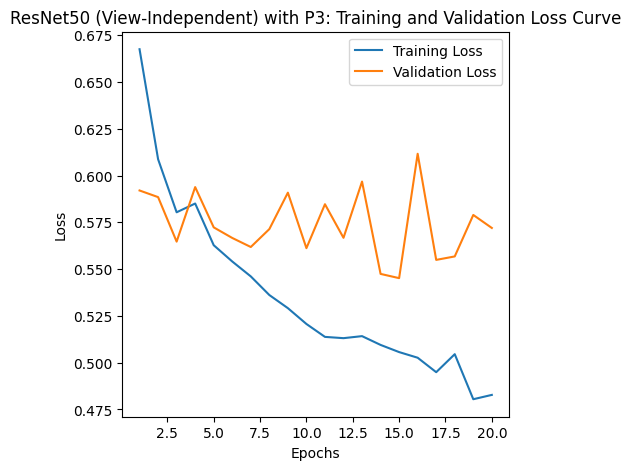

In [ ]:
# Training-Validation Loss curve for P3 pipeline
plot_training_validation_loss(resnet50_p3.history, 'ResNet50 (View-Independent)', 'P3')

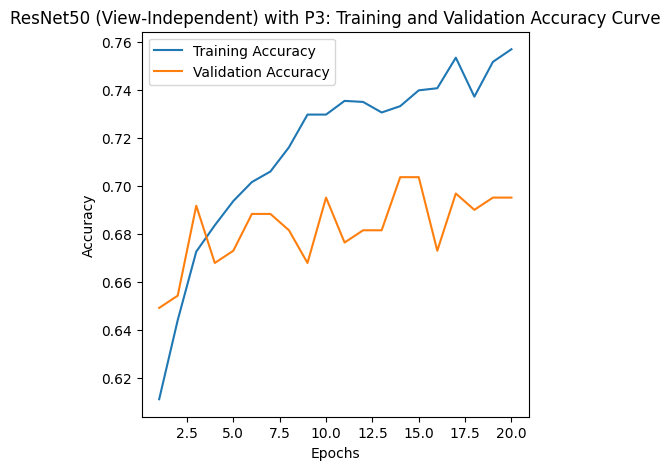

In [ ]:
# Training-Validation Accuracy curve for P3 pipeline
plot_training_validation_accuracy(resnet50_p3.history, 'ResNet50 (View-Independent)', 'P3')

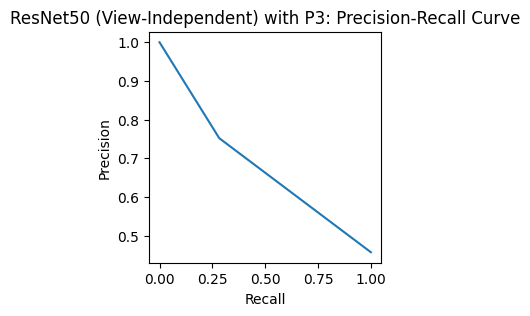

In [ ]:
# Precision-Recall curve for P3 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p3, 'ResNet50 (View-Independent)', 'P3')

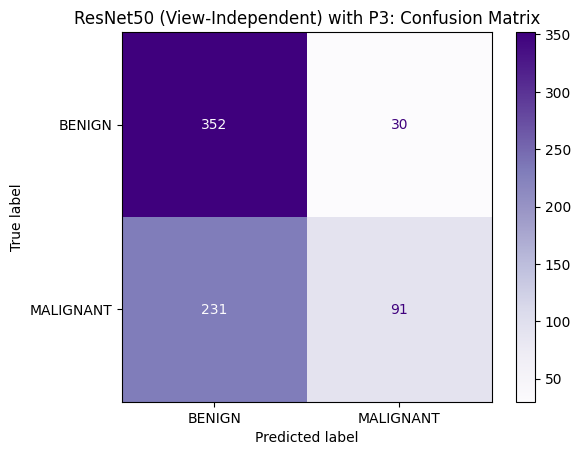

In [ ]:
# Confusion matrix for P3 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p3, 'ResNet50 (View-Independent)', 'P3')

## P4 Image Preprocessing Pipeline Experiment

* Resizing
* Median Blur
* Normalization

In [ ]:
# Select the p4 image preprocessor function from the image preprocessor dictionary
p4 = IMAGE_PREPROCESSORS['P4']

In [ ]:
# Create a tf.data dataset with p4 image preprocessing
train_dataset_p4 = generate_dataset(train_df, 32, p4, 'resnet50', training=True)
val_dataset_p4 = generate_dataset(val_df, 32, p4, 'resnet50', training=False)
test_dataset_p4 = generate_dataset(test_df, 32, p4, 'resnet50', training=False)

In [ ]:
# Create a Resnet50 model for p4 pipeline
resnet50_p4 = create_resnet50_model()
resnet50_p4 = compile_model(resnet50_p4)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
# Train ResNet50 with training dataset for p4 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p4
train_start_p4 = time.time()

# ResNet50 with p4 training for 20 epochs
resnet50_p4.fit(train_dataset_p4, validation_data=val_dataset_p4, epochs=20)

# Memory used in p4
peak_memory_p4 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p4
train_end_p4 = time.time()

# Total training time for p4 in minutes
training_time_p4 = (train_end_p4 - train_start_p4)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 66s 233ms/step - accuracy: 0.6079 - auc: 0.6231 - loss: 0.6781 - precision: 0.5081 - recall: 0.4148 - val_accuracy: 0.6797 - val_auc: 0.7236 - val_loss: 0.5839 - val_precision: 0.6040 - val_recall: 0.5304
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 74s 183ms/step - accuracy: 0.6611 - auc: 0.6980 - loss: 0.6060 - precision: 0.5902 - recall: 0.4812 - val_accuracy: 0.7070 - val_auc: 0.7529 - val_loss: 0.5629 - val_precision: 0.6648 - val_recall: 0.5087
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 192ms/step - accuracy: 0.6866 - auc: 0.7406 - loss: 0.5749 - precision: 0.6265 - recall: 0.5232 - val_accuracy: 0.7172 - val_auc: 0.7681 - val_loss: 0.5555 - val_precision: 0.6509 - val_recall: 0.6000
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 50s 187ms/step - accuracy: 0.6725 - auc: 0.7329 - loss: 0.5812 - precision: 0.6034 - recall: 0.5133 - val_accuracy: 0.7036 - val_auc: 0.7644 - val_loss: 0.5616 - val_precision: 0.7456 - val_recall: 0.3696
Epoch 5/20
72/72 ━━━━━━━━━━━

### P4 Image Preprocessing Predictions

In [ ]:
# Predict Resnet50's prediction probabilities using test data for p4

# Prediction start time
predict_start_p4 = time.time()

# Resnet50 with p4 predictions
prediction_probs_p4 = resnet50_p4.predict(test_dataset_p4)

# Prediction end time
predict_end_p4 = time.time()

# Total prediction time for p4 in seconds
prediction_time_p4 = predict_end_p4 - predict_start_p4

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 255ms/step


In [ ]:
# Evaluation metrics for Resnet50 with p4
eval_metrics_p4 = resnet50_p4.evaluate(test_dataset_p4, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.6449 - auc: 0.7201 - loss: 0.6302 - precision: 0.7045 - recall: 0.3851


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p4 = np.where(prediction_probs_p4 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p4 true and predicted values
tn_p4, fp_p4, fn_p4, tp_p4 = confusion_matrix(true_pathology, predictions_p4).ravel()

# Compute specificity using CM
specificity_p4 = tn_p4 / (tn_p4 + fp_p4)

# Compute F1 Score using recall and precision
f1_score_p4 = 0.0
if eval_metrics_p4['precision'] + eval_metrics_p4['recall'] != 0.0:
  f1_score_p4 = (2 * eval_metrics_p4['precision'] * eval_metrics_p4['recall']) / (eval_metrics_p4['precision'] + eval_metrics_p4['recall'])

# Parameters of ResNet50 View-Independent model
resnet50_params_p4 = resnet50_p4.count_params()

In [ ]:
# Generate a results dataframe for results of p4 experiment
results_p4 = generate_results_df('ResNet50', 'View_Independent', 'P4', eval_metrics_p4, specificity_p4, f1_score_p4, training_time_p4, prediction_time_p4, peak_memory_p4, resnet50_params_p4)

# Store p4 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p4)

Stored results for 0    P4
Name: image_preprocessing_pipeline, dtype: object pipeline


### P4 Image Preprocessing Graphs

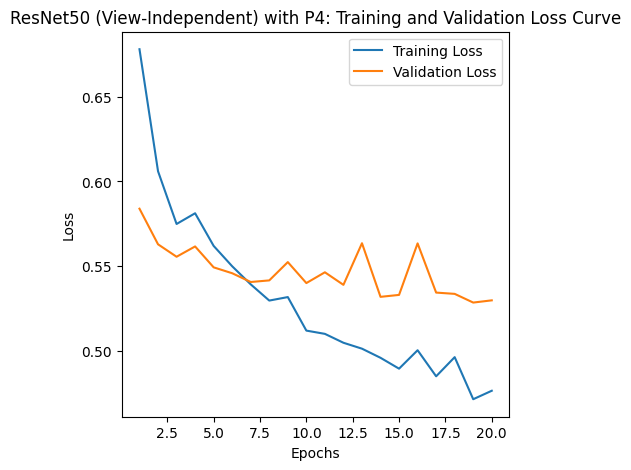

In [ ]:
# Training-Validation Loss curve for P4 pipeline
plot_training_validation_loss(resnet50_p4.history, 'ResNet50 (View-Independent)', 'P4')

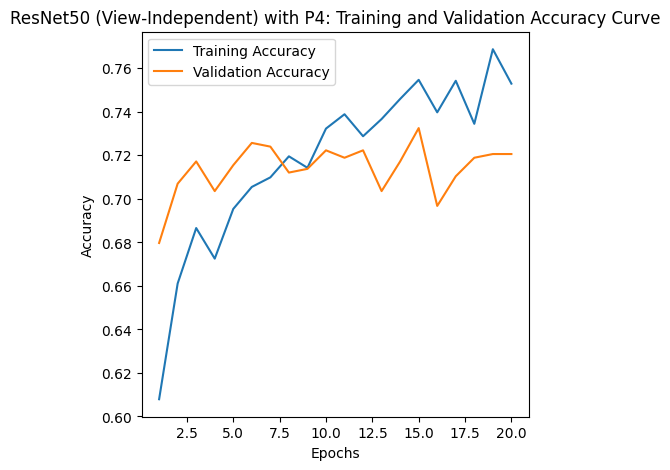

In [ ]:
# Training-Validation Accuracy curve for P4 pipeline
plot_training_validation_accuracy(resnet50_p4.history, 'ResNet50 (View-Independent)', 'P4')

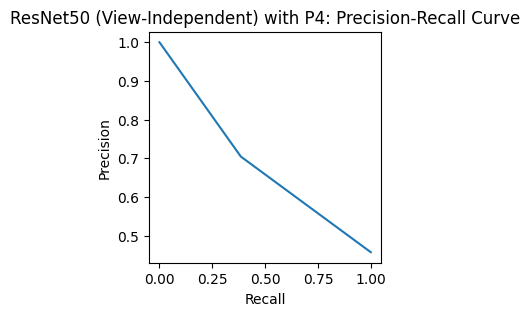

In [ ]:
# Precision-Recall curve for P4 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p4, 'ResNet50 (View-Independent)', 'P4')

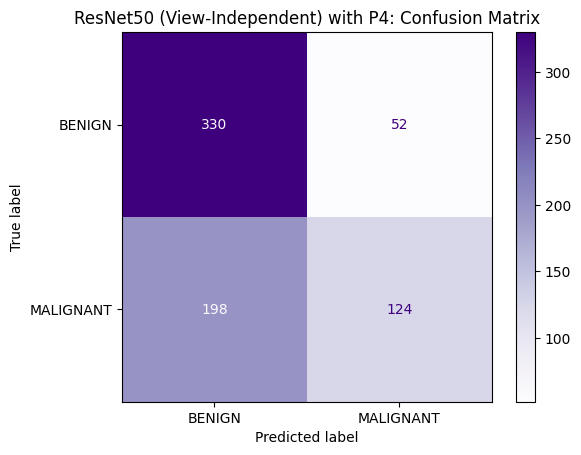

In [ ]:
# Confusion matrix for P4 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p4, 'ResNet50 (View-Independent)', 'P4')

## P5 Image Preprocessing Pipeline Experiment

* Resizing
* Grayscaling
* Gamma Correction
* Normalization

In [ ]:
# Select the p5 image preprocessor function from the image preprocessor dictionary
p5 = IMAGE_PREPROCESSORS['P5']

In [ ]:
# Create a tf.data dataset with p5 image preprocessing
train_dataset_p5 = generate_dataset(train_df, 32, p5, 'resnet50', training=True)
val_dataset_p5 = generate_dataset(val_df, 32, p5, 'resnet50', training=False)
test_dataset_p5 = generate_dataset(test_df, 32, p5, 'resnet50', training=False)

In [ ]:
# Create a Resnet50 model for p5 pipeline
resnet50_p5 = create_resnet50_model()
resnet50_p5 = compile_model(resnet50_p5)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Train ResNet50 with training dataset for p5 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p5
train_start_p5 = time.time()

# ResNet50 with p5 training for 20 epochs
resnet50_p5.fit(train_dataset_p5, validation_data=val_dataset_p5, epochs=20)

# Memory used in p5
peak_memory_p5 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p5
train_end_p5 = time.time()

# Total training time for p5 in minutes
training_time_p5 = (train_end_p5 - train_start_p5)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 65s 217ms/step - accuracy: 0.6110 - auc: 0.6225 - loss: 0.6675 - precision: 0.5134 - recall: 0.4015 - val_accuracy: 0.6491 - val_auc: 0.7005 - val_loss: 0.5920 - val_precision: 0.5845 - val_recall: 0.3609
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 180ms/step - accuracy: 0.6440 - auc: 0.6930 - loss: 0.6087 - precision: 0.5651 - recall: 0.4513 - val_accuracy: 0.6542 - val_auc: 0.7114 - val_loss: 0.5885 - val_precision: 0.6239 - val_recall: 0.2957
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 189ms/step - accuracy: 0.6725 - auc: 0.7281 - loss: 0.5804 - precision: 0.6067 - recall: 0.5000 - val_accuracy: 0.6917 - val_auc: 0.7446 - val_loss: 0.5647 - val_precision: 0.6561 - val_recall: 0.4478
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 50s 181ms/step - accuracy: 0.6835 - auc: 0.7247 - loss: 0.5851 - precision: 0.6201 - recall: 0.5254 - val_accuracy: 0.6678 - val_auc: 0.7320 - val_loss: 0.5938 - val_precision: 0.7333 - val_recall: 0.2391
Epoch 5/20
72/72 ━━━━━━━━━━━

### P5 Image Preprocessing Predictions

In [ ]:
# Predict Resnet50's prediction probabilities using test data for p5

# Prediction start time
predict_start_p5 = time.time()

# Resnet50 with p5 predictions
prediction_probs_p5 = resnet50_p5.predict(test_dataset_p5)

# Prediction end time
predict_end_p5 = time.time()

# Total prediction time for p5 in seconds
prediction_time_p5 = predict_end_p5 - predict_start_p5

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step


In [ ]:
# Evaluation metrics for Resnet50 with p5
eval_metrics_p5 = resnet50_p5.evaluate(test_dataset_p5, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 229ms/step - accuracy: 0.6293 - auc: 0.7403 - loss: 0.6665 - precision: 0.7521 - recall: 0.2826


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p5 = np.where(prediction_probs_p5 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p5 true and predicted values
tn_p5, fp_p5, fn_p5, tp_p5 = confusion_matrix(true_pathology, predictions_p5).ravel()

# Compute specificity using CM
specificity_p5 = tn_p5 / (tn_p5 + fp_p5)

# Compute F1 Score using recall and precision
f1_score_p5 = 0.0
if eval_metrics_p5['precision'] + eval_metrics_p5['recall'] != 0.0:
  f1_score_p5 = (2 * eval_metrics_p5['precision'] * eval_metrics_p5['recall']) / (eval_metrics_p5['precision'] + eval_metrics_p5['recall'])

# Parameters of ResNet50 View-Independent model
resnet50_params_p5 = resnet50_p5.count_params()

In [ ]:
# Generate a results dataframe for results of p5 experiment
results_p5 = generate_results_df('ResNet50', 'View_Independent', 'P5', eval_metrics_p5, specificity_p5, f1_score_p5, training_time_p5, prediction_time_p5, peak_memory_p5, resnet50_params_p5)

# Store p5 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p5)

Stored results for 0    P5
Name: image_preprocessing_pipeline, dtype: object pipeline


### P5 Image Preprocessing Graphs

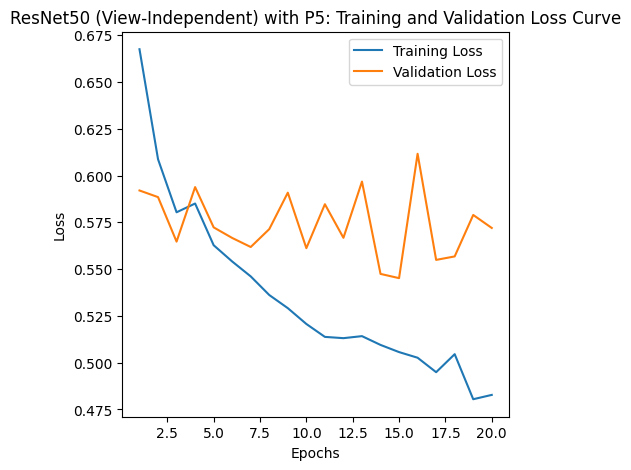

In [ ]:
# Training-Validation Loss curve for P5 pipeline
plot_training_validation_loss(resnet50_p5.history, 'ResNet50 (View-Independent)', 'P5')

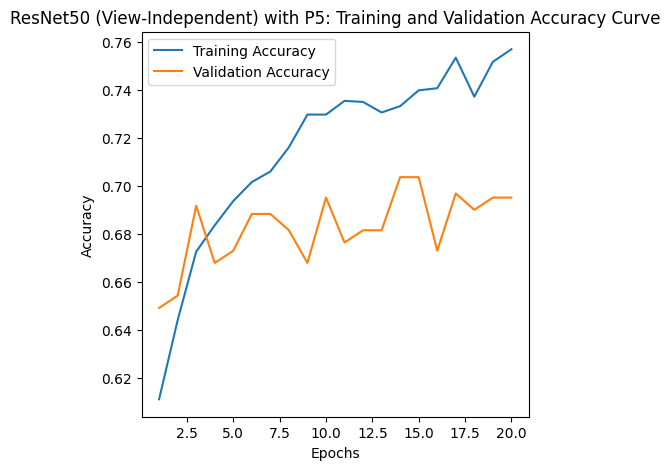

In [ ]:
# Training-Validation Accuracy curve for P5 pipeline
plot_training_validation_accuracy(resnet50_p5.history, 'ResNet50 (View-Independent)', 'P5')

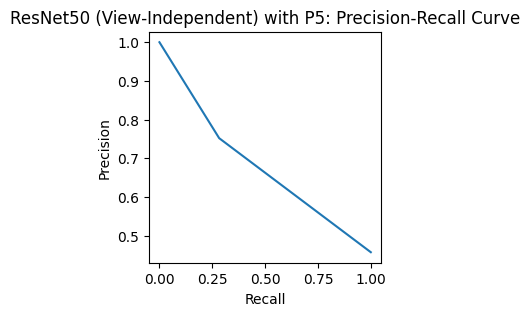

In [ ]:
# Precision-Recall curve for P5 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p5, 'ResNet50 (View-Independent)', 'P5')

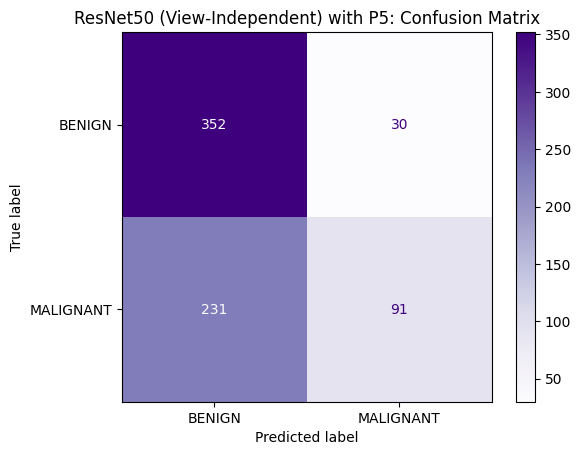

In [ ]:
# Confusion matrix for P5 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p5, 'ResNet50 (View-Independent)', 'P5')

## P6 Image Preprocessing Pipeline Experiment

* Resizing
* Grayscaling
* Median Blur
* Normalization

In [ ]:
# Select the p6 image preprocessor function from the image preprocessor dictionary
p6 = IMAGE_PREPROCESSORS['P6']

In [ ]:
# Create a tf.data dataset with p6 image preprocessing
train_dataset_p6 = generate_dataset(train_df, 32, p6, 'resnet50', training=True)
val_dataset_p6 = generate_dataset(val_df, 32, p6, 'resnet50', training=False)
test_dataset_p6 = generate_dataset(test_df, 32, p6, 'resnet50', training=False)

In [ ]:
# Create a Resnet50 model for p6 pipeline
resnet50_p6 = create_resnet50_model()
resnet50_p6 = compile_model(resnet50_p6)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train Resnet50 with training dataset for p6 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p6
train_start_p6 = time.time()

# Resnet50 with p6 training for 20 epochs
resnet50_p6.fit(train_dataset_p6, validation_data=val_dataset_p6, epochs=20)

# Memory used in p6
peak_memory_p6 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p6
train_end_p6 = time.time()

# Total training time for p6 in minutes
training_time_p6 = (train_end_p6 - train_start_p6)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 68s 227ms/step - accuracy: 0.6079 - auc: 0.6231 - loss: 0.6781 - precision: 0.5081 - recall: 0.4148 - val_accuracy: 0.6797 - val_auc: 0.7236 - val_loss: 0.5839 - val_precision: 0.6040 - val_recall: 0.5304
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 55s 196ms/step - accuracy: 0.6611 - auc: 0.6980 - loss: 0.6060 - precision: 0.5902 - recall: 0.4812 - val_accuracy: 0.7070 - val_auc: 0.7529 - val_loss: 0.5629 - val_precision: 0.6648 - val_recall: 0.5087
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 54s 207ms/step - accuracy: 0.6866 - auc: 0.7406 - loss: 0.5749 - precision: 0.6265 - recall: 0.5232 - val_accuracy: 0.7172 - val_auc: 0.7681 - val_loss: 0.5555 - val_precision: 0.6509 - val_recall: 0.6000
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 53s 204ms/step - accuracy: 0.6725 - auc: 0.7329 - loss: 0.5812 - precision: 0.6034 - recall: 0.5133 - val_accuracy: 0.7036 - val_auc: 0.7644 - val_loss: 0.5616 - val_precision: 0.7456 - val_recall: 0.3696
Epoch 5/20
72/72 ━━━━━━━━━━━

### P6 Image Preprocessing Predictions

In [ ]:
# Predict Resnet50's prediction probabilities using test data for p6

# Prediction start time
predict_start_p6 = time.time()

# Resnet50 with p6 predictions
prediction_probs_p6 = resnet50_p6.predict(test_dataset_p6)

# Prediction end time
predict_end_p6 = time.time()

# Total prediction time for p6 in seconds
prediction_time_p6 = predict_end_p6 - predict_start_p6

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 225ms/step


In [ ]:
# Evaluation metrics for Resnet50 with p6
eval_metrics_p6 = resnet50_p6.evaluate(test_dataset_p6, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.6449 - auc: 0.7201 - loss: 0.6302 - precision: 0.7045 - recall: 0.3851


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p6 = np.where(prediction_probs_p6 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p6 true and predicted values
tn_p6, fp_p6, fn_p6, tp_p6 = confusion_matrix(true_pathology, predictions_p6).ravel()

# Compute specificity using CM
specificity_p6 = tn_p6 / (tn_p6 + fp_p6)

# Compute F1 Score using recall and precision
f1_score_p6 = 0.0
if eval_metrics_p6['precision'] + eval_metrics_p6['recall'] != 0.0:
  f1_score_p6 = (2 * eval_metrics_p6['precision'] * eval_metrics_p6['recall']) / (eval_metrics_p6['precision'] + eval_metrics_p6['recall'])

# Parameters of Resnet50 View-Independent model
resnet50_params_p6 = resnet50_p6.count_params()

In [ ]:
# Generate a results dataframe for results of p6 experiment
results_p6 = generate_results_df('ResNet50', 'View_Independent', 'P6', eval_metrics_p6, specificity_p6, f1_score_p6, training_time_p6, prediction_time_p6, peak_memory_p6, resnet50_params_p6)

# Store p6 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p6)

Stored results for 0    P6
Name: image_preprocessing_pipeline, dtype: object pipeline


### P6 Image Preprocessing Graphs

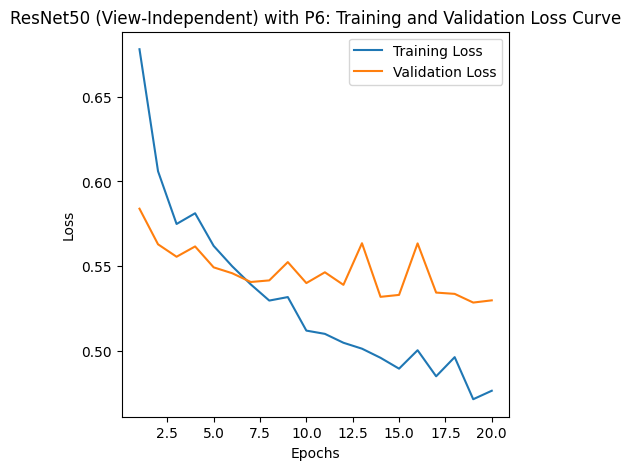

In [ ]:
# Training-Validation Loss curve for P6 pipeline
plot_training_validation_loss(resnet50_p6.history, 'ResNet50 (View-Independent)', 'P6')

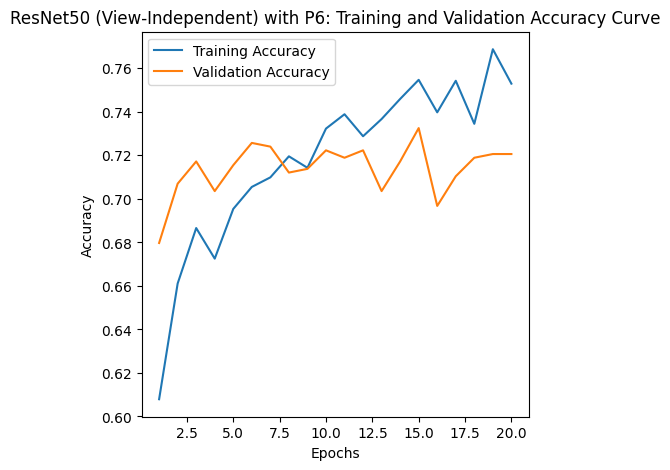

In [ ]:
# Training-Validation Accuracy curve for P6 pipeline
plot_training_validation_accuracy(resnet50_p6.history, 'ResNet50 (View-Independent)', 'P6')

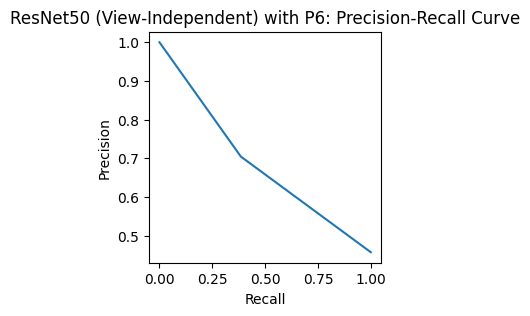

In [ ]:
# Precision-Recall curve for P6 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p6, 'ResNet50 (View-Independent)', 'P6')

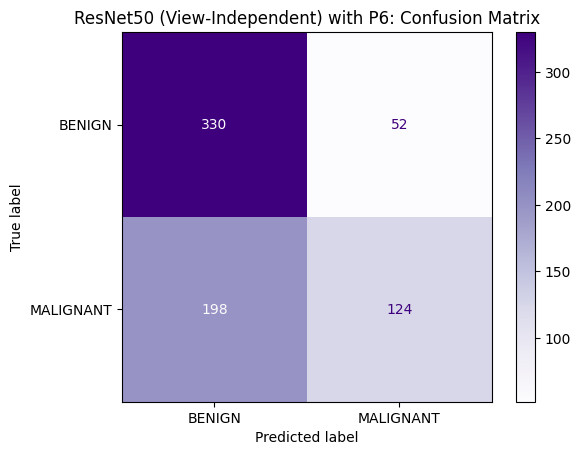

In [ ]:
# Confusion matrix for P6 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p6, 'ResNet50 (View-Independent)', 'P6')

## P7 Image Preprocessing Pipeline Experiment

* Resizing
* CLAHE
* Gamma Correction
* Normalization

In [ ]:
# Select the p7 image preprocessor function from the image preprocessor dictionary
p7 = IMAGE_PREPROCESSORS['P7']

In [ ]:
# Create a tf.data dataset with p7 image preprocessing
train_dataset_p7 = generate_dataset(train_df, 32, p7, 'resnet50', training=True)
val_dataset_p7 = generate_dataset(val_df, 32, p7, 'resnet50', training=False)
test_dataset_p7 = generate_dataset(test_df, 32, p7, 'resnet50', training=False)

In [ ]:
# Create a Resnet50 model for p7 pipeline
resnet50_p7 = create_resnet50_model()
resnet50_p7 = compile_model(resnet50_p7)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train Resnet50 with training dataset for p7 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p7
train_start_p7 = time.time()

# Resnet50 with p7 training for 20 epochs
resnet50_p7.fit(train_dataset_p7, validation_data=val_dataset_p7, epochs=20)

# Memory used in p7
peak_memory_p7 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p7
train_end_p7 = time.time()

# Total training time for p7 in minutes
training_time_p7 = (train_end_p7 - train_start_p7)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 69s 232ms/step - accuracy: 0.6062 - auc: 0.6269 - loss: 0.6634 - precision: 0.5055 - recall: 0.4038 - val_accuracy: 0.6422 - val_auc: 0.6955 - val_loss: 0.5926 - val_precision: 0.5658 - val_recall: 0.3739
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 54s 195ms/step - accuracy: 0.6523 - auc: 0.6981 - loss: 0.6048 - precision: 0.5808 - recall: 0.4491 - val_accuracy: 0.6525 - val_auc: 0.7127 - val_loss: 0.5901 - val_precision: 0.6182 - val_recall: 0.2957
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 55s 200ms/step - accuracy: 0.6826 - auc: 0.7382 - loss: 0.5742 - precision: 0.6201 - recall: 0.5199 - val_accuracy: 0.6746 - val_auc: 0.7427 - val_loss: 0.5648 - val_precision: 0.6211 - val_recall: 0.4348
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 55s 207ms/step - accuracy: 0.6774 - auc: 0.7227 - loss: 0.5862 - precision: 0.6113 - recall: 0.5166 - val_accuracy: 0.6763 - val_auc: 0.7323 - val_loss: 0.5907 - val_precision: 0.7564 - val_recall: 0.2565
Epoch 5/20
72/72 ━━━━━━━━━━━

### P7 Image Preprocessing Predictions

In [ ]:
# Predict Resnet50's prediction probabilities using test data for p7

# Prediction start time
predict_start_p7 = time.time()

# Resnet50 with p7 predictions
prediction_probs_p7 = resnet50_p7.predict(test_dataset_p7)

# Prediction end time
predict_end_p7 = time.time()

# Total prediction time for p7 in seconds
prediction_time_p7 = predict_end_p7 - predict_start_p7

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 259ms/step


In [ ]:
# Evaluation metrics for Resnet50 with p7
eval_metrics_p7 = resnet50_p7.evaluate(test_dataset_p7, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 283ms/step - accuracy: 0.6250 - auc: 0.7513 - loss: 0.6860 - precision: 0.7900 - recall: 0.2453


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p7 = np.where(prediction_probs_p7 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p7 true and predicted values
tn_p7, fp_p7, fn_p7, tp_p7 = confusion_matrix(true_pathology, predictions_p7).ravel()

# Compute specificity using CM
specificity_p7 = tn_p7 / (tn_p7 + fp_p7)

# Compute F1 Score using recall and precision
f1_score_p7 = 0.0
if eval_metrics_p7['precision'] + eval_metrics_p7['recall'] != 0.0:
  f1_score_p7 = (2 * eval_metrics_p7['precision'] * eval_metrics_p7['recall']) / (eval_metrics_p7['precision'] + eval_metrics_p7['recall'])

# Parameters of Resnet50 View-Independent model
resnet50_params_p7 = resnet50_p7.count_params()

In [ ]:
# Generate a results dataframe for results of p7 experiment
results_p7 = generate_results_df('ResNet50', 'View_Independent', 'P7', eval_metrics_p7, specificity_p7, f1_score_p7, training_time_p7, prediction_time_p7, peak_memory_p7, resnet50_params_p7)

# Store p7 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p7)

Stored results for 0    P7
Name: image_preprocessing_pipeline, dtype: object pipeline


### P7 Image Preprocessing Graphs

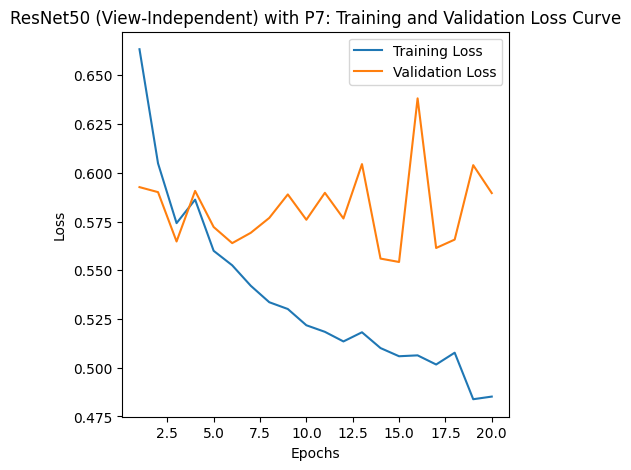

In [ ]:
# Training-Validation Loss curve for P7 pipeline
plot_training_validation_loss(resnet50_p7.history, 'ResNet50 (View-Independent)', 'P7')

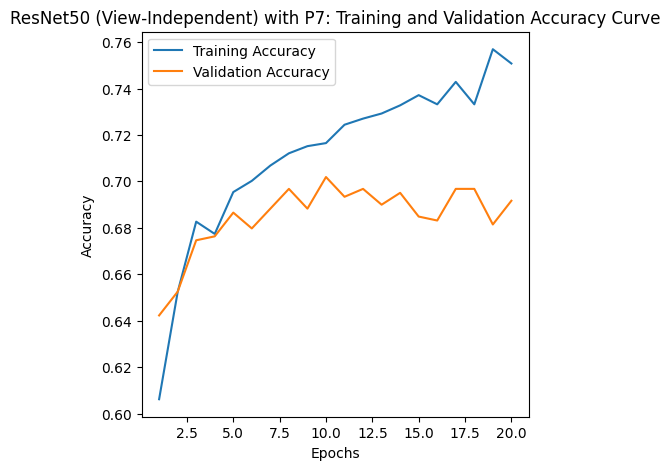

In [ ]:
# Training-Validation Accuracy curve for P7 pipeline
plot_training_validation_accuracy(resnet50_p7.history, 'ResNet50 (View-Independent)', 'P7')

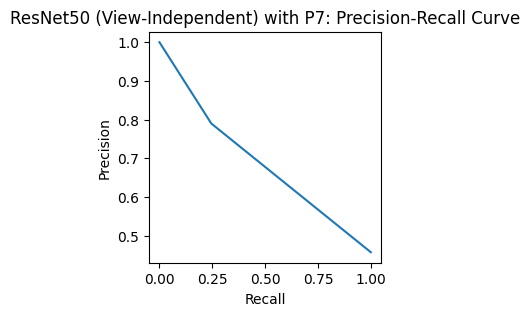

In [ ]:
# Precision-Recall curve for P7 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p7, 'ResNet50 (View-Independent)', 'P7')

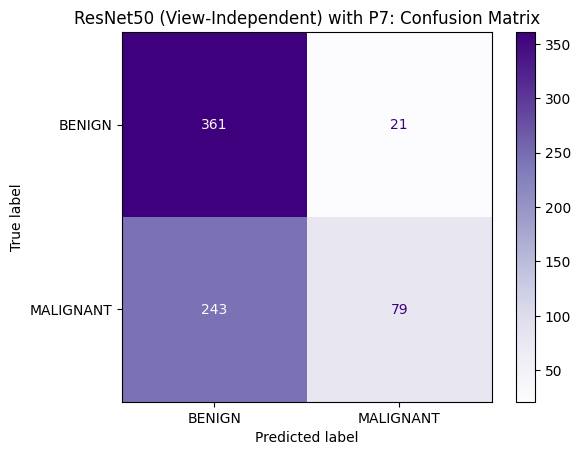

In [ ]:
# Confusion matrix for P7 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p7, 'ResNet50 (View-Independent)', 'P7')

## P8 Image Preprocessing Pipeline Experiment

* Resizing
* CLAHE
* Median Blur
* Normalization

In [ ]:
# Select the p8 image preprocessor function from the image preprocessor dictionary
p8 = IMAGE_PREPROCESSORS['P8']

In [ ]:
# Create a tf.data dataset with p8 image preprocessing
train_dataset_p8 = generate_dataset(train_df, 32, p8, 'resnet50', training=True)
val_dataset_p8 = generate_dataset(val_df, 32, p8, 'resnet50', training=False)
test_dataset_p8 = generate_dataset(test_df, 32, p8, 'resnet50', training=False)

In [ ]:
# Create a ResNet50 model for p8 pipeline
resnet50_p8 = create_resnet50_model()
resnet50_p8 = compile_model(resnet50_p8)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train ResNet50 with training dataset for p8 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p8
train_start_p8 = time.time()

# ResNet50 with p8 training for 20 epochs
resnet50_p8.fit(train_dataset_p8, validation_data=val_dataset_p8, epochs=20)

# Memory used in p8
peak_memory_p8 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p8
train_end_p8 = time.time()

# Total training time for p8 in minutes
training_time_p8 = (train_end_p8 - train_start_p8)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 69s 237ms/step - accuracy: 0.6066 - auc: 0.6284 - loss: 0.6779 - precision: 0.5059 - recall: 0.4248 - val_accuracy: 0.6576 - val_auc: 0.7114 - val_loss: 0.5933 - val_precision: 0.5587 - val_recall: 0.6000
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 55s 204ms/step - accuracy: 0.6484 - auc: 0.6958 - loss: 0.6101 - precision: 0.5691 - recall: 0.4735 - val_accuracy: 0.6763 - val_auc: 0.7415 - val_loss: 0.5733 - val_precision: 0.5820 - val_recall: 0.6174
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 56s 219ms/step - accuracy: 0.6901 - auc: 0.7435 - loss: 0.5743 - precision: 0.6291 - recall: 0.5365 - val_accuracy: 0.6899 - val_auc: 0.7519 - val_loss: 0.5703 - val_precision: 0.5960 - val_recall: 0.6478
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 54s 212ms/step - accuracy: 0.6659 - auc: 0.7321 - loss: 0.5828 - precision: 0.5935 - recall: 0.5055 - val_accuracy: 0.7019 - val_auc: 0.7519 - val_loss: 0.5672 - val_precision: 0.6923 - val_recall: 0.4304
Epoch 5/20
72/72 ━━━━━━━━━━━

### P8 Image Preprocessing Predictions

In [ ]:
# Predict Resnet50's prediction probabilities using test data for p8

# Prediction start time
predict_start_p8 = time.time()

# Resnet50 with p8 predictions
prediction_probs_p8 = resnet50_p8.predict(test_dataset_p8)

# Prediction end time
predict_end_p8 = time.time()

# Total prediction time for p8 in seconds
prediction_time_p8 = predict_end_p8 - predict_start_p8

22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 274ms/step


In [ ]:
# Evaluation metrics for Resnet50 with p8
eval_metrics_p8 = resnet50_p8.evaluate(test_dataset_p8, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step - accuracy: 0.6321 - auc: 0.7256 - loss: 0.6131 - precision: 0.6537 - recall: 0.4161


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p8 = np.where(prediction_probs_p8 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p8 true and predicted values
tn_p8, fp_p8, fn_p8, tp_p8 = confusion_matrix(true_pathology, predictions_p8).ravel()

# Compute specificity using CM
specificity_p8 = tn_p8 / (tn_p8 + fp_p8)

# Compute F1 Score using recall and precision
f1_score_p8 = 0.0
if eval_metrics_p8['precision'] + eval_metrics_p8['recall'] != 0.0:
  f1_score_p8 = (2 * eval_metrics_p8['precision'] * eval_metrics_p8['recall']) / (eval_metrics_p8['precision'] + eval_metrics_p8['recall'])

# Parameters of Resnet50 View-Independent model
resnet50_params_p8 = resnet50_p8.count_params()

In [ ]:
# Generate a results dataframe for results of p8 experiment
results_p8 = generate_results_df('ResNet50', 'View_Independent', 'P8', eval_metrics_p8, specificity_p8, f1_score_p8, training_time_p8, prediction_time_p8, peak_memory_p8, resnet50_params_p8)

# Store p8 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p8)

Stored results for 0    P8
Name: image_preprocessing_pipeline, dtype: object pipeline


### P8 Image Preprocessing Graphs

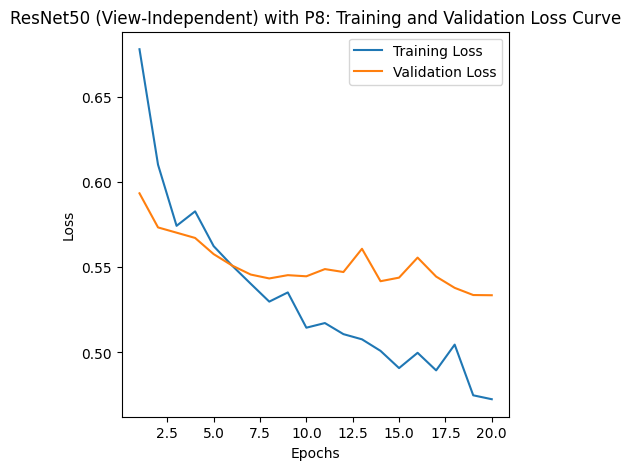

In [ ]:
# Training-Validation Loss curve for P8 pipeline
plot_training_validation_loss(resnet50_p8.history, 'ResNet50 (View-Independent)', 'P8')

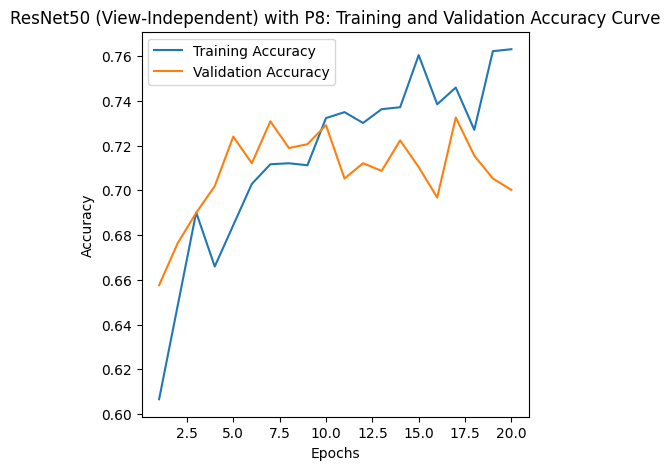

In [ ]:
# Training-Validation Accuracy curve for P8 pipeline
plot_training_validation_accuracy(resnet50_p8.history, 'ResNet50 (View-Independent)', 'P8')

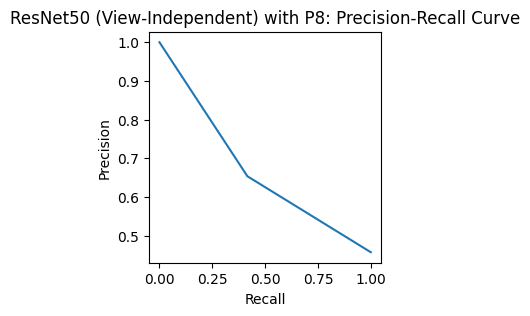

In [ ]:
# Precision-Recall curve for P8 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p8, 'ResNet50 (View-Independent)', 'P8')

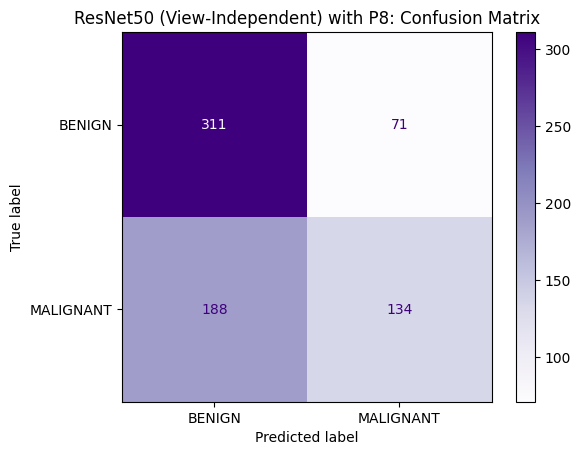

In [ ]:
# Confusion matrix for P8 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p8, 'ResNet50 (View-Independent)', 'P8')

## P9 Image Preprocessing Pipeline Experiment

* Resizing
* Gamma Correction
* Median Blur
* Normalization

In [ ]:
# Select the p9 image preprocessor function from the image preprocessor dictionary
p9 = IMAGE_PREPROCESSORS['P9']

In [ ]:
# Create a tf.data dataset with p9 image preprocessing
train_dataset_p9 = generate_dataset(train_df, 32, p9, 'resnet50', training=True)
val_dataset_p9 = generate_dataset(val_df, 32, p9, 'resnet50', training=False)
test_dataset_p9 = generate_dataset(test_df, 32, p9, 'resnet50', training=False)

In [ ]:
# Create a Resnet50 model for p9 pipeline
resnet50_p9 = create_resnet50_model()
resnet50_p9 = compile_model(resnet50_p9)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train Resnet50 with training dataset for p9 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p9
train_start_p9 = time.time()

# Resnet50 with p9 training for 20 epochs
resnet50_p9.fit(train_dataset_p9, validation_data=val_dataset_p9, epochs=20)

# Memory used in p9
peak_memory_p9 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p9
train_end_p9 = time.time()

# Total training time for p9 in minutes
training_time_p9 = (train_end_p9 - train_start_p9)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 69s 233ms/step - accuracy: 0.6018 - auc: 0.6131 - loss: 0.6686 - precision: 0.4985 - recall: 0.3717 - val_accuracy: 0.6542 - val_auc: 0.7009 - val_loss: 0.5934 - val_precision: 0.5707 - val_recall: 0.4739
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 54s 199ms/step - accuracy: 0.6527 - auc: 0.6895 - loss: 0.6097 - precision: 0.5819 - recall: 0.4480 - val_accuracy: 0.6746 - val_auc: 0.7207 - val_loss: 0.5794 - val_precision: 0.6327 - val_recall: 0.4043
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 188ms/step - accuracy: 0.6695 - auc: 0.7208 - loss: 0.5862 - precision: 0.6041 - recall: 0.4878 - val_accuracy: 0.6882 - val_auc: 0.7338 - val_loss: 0.5680 - val_precision: 0.6243 - val_recall: 0.5130
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 53s 192ms/step - accuracy: 0.6716 - auc: 0.7176 - loss: 0.5905 - precision: 0.6029 - recall: 0.5088 - val_accuracy: 0.6814 - val_auc: 0.7344 - val_loss: 0.5767 - val_precision: 0.7363 - val_recall: 0.2913
Epoch 5/20
72/72 ━━━━━━━━━━━

### P9 Image Preprocessing Predictions

In [ ]:
# Predict Resnet50's prediction probabilities using test data for p9

# Prediction start time
predict_start_p9 = time.time()

# Resnet50 with p9 predictions
prediction_probs_p9 = resnet50_p9.predict(test_dataset_p9)

# Prediction end time
predict_end_p9 = time.time()

# Total prediction time for p9 in seconds
prediction_time_p9 = predict_end_p9 - predict_start_p9

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 241ms/step


In [ ]:
# Evaluation metrics for Resnet50 with p9
eval_metrics_p9 = resnet50_p9.evaluate(test_dataset_p9, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 288ms/step - accuracy: 0.6420 - auc: 0.7226 - loss: 0.6490 - precision: 0.7160 - recall: 0.3602


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p9 = np.where(prediction_probs_p9 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p9 true and predicted values
tn_p9, fp_p9, fn_p9, tp_p9 = confusion_matrix(true_pathology, predictions_p9).ravel()

# Compute specificity using CM
specificity_p9 = tn_p9 / (tn_p9 + fp_p9)

# Compute F1 Score using recall and precision
f1_score_p9 = 0.0
if eval_metrics_p9['precision'] + eval_metrics_p9['recall'] != 0.0:
  f1_score_p9 = (2 * eval_metrics_p9['precision'] * eval_metrics_p9['recall']) / (eval_metrics_p9['precision'] + eval_metrics_p9['recall'])

# Parameters of ResNet50 View-Independent model
resnet50_params_p9 = resnet50_p9.count_params()

In [ ]:
# Generate a results dataframe for results of p9 experiment
results_p9 = generate_results_df('ResNet50', 'View_Independent', 'P9', eval_metrics_p9, specificity_p9, f1_score_p9, training_time_p9, prediction_time_p9, peak_memory_p9, resnet50_params_p9)

# Store p9 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p9)

Stored results for 0    P9
Name: image_preprocessing_pipeline, dtype: object pipeline


### P9 Image Preprocessing Graphs

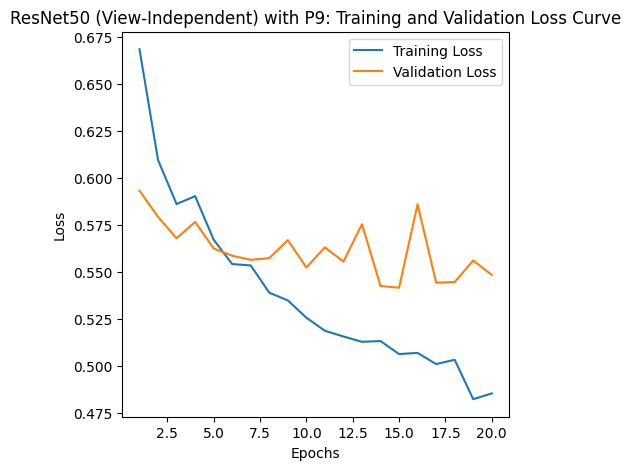

In [ ]:
# Training-Validation Loss curve for P9 pipeline
plot_training_validation_loss(resnet50_p9.history, 'ResNet50 (View-Independent)', 'P9')

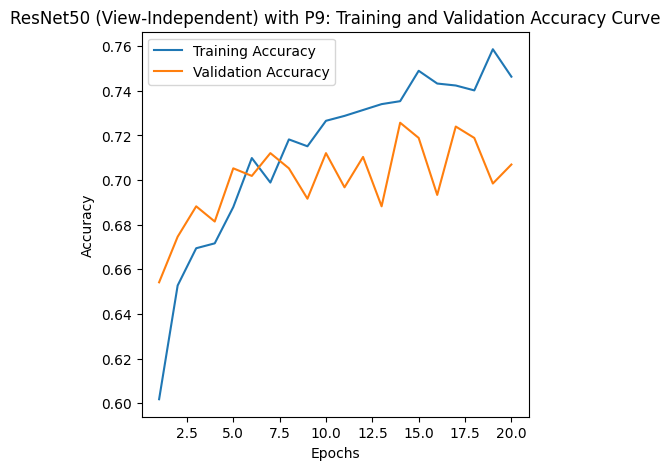

In [ ]:
# Training-Validation Accuracy curve for P9 pipeline
plot_training_validation_accuracy(resnet50_p9.history, 'ResNet50 (View-Independent)', 'P9')

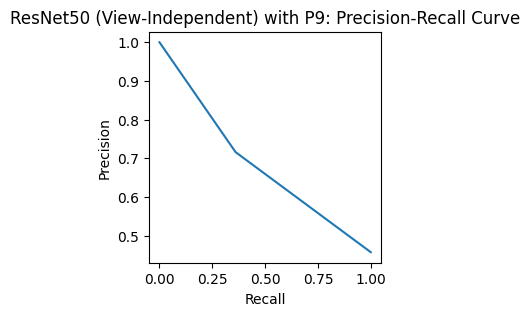

In [ ]:
# Precision-Recall curve for P9 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p9, 'ResNet50 (View-Independent)', 'P9')

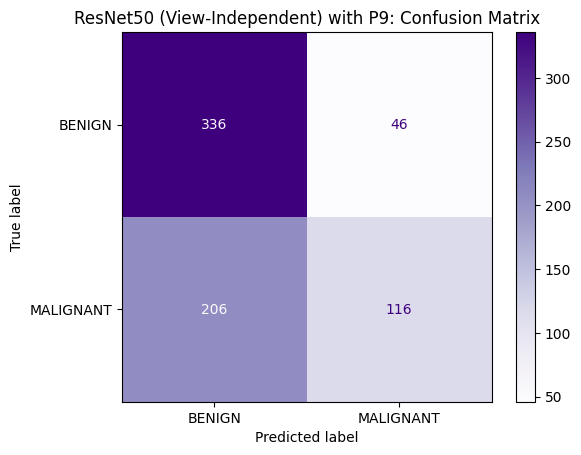

In [ ]:
# Confusion matrix for P9 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p9, 'ResNet50 (View-Independent)', 'P9')

## P10 Image Preprocessing Pipeline Experiment

* Resizing
* Grayscaling
* CLAHE
* Gamma Correction
* Median Blur
* Normalization

In [ ]:
# Select the p10 image preprocessor function from the image preprocessor dictionary
p10 = IMAGE_PREPROCESSORS['P10']

In [ ]:
# Create a tf.data dataset with p10 image preprocessing
train_dataset_p10 = generate_dataset(train_df, 32, p10, 'resnet50', training=True)
val_dataset_p10 = generate_dataset(val_df, 32, p10, 'resnet50', training=False)
test_dataset_p10 = generate_dataset(test_df, 32, p10, 'resnet50', training=False)

In [ ]:
# Create a Resnet50 model for p10 pipeline
resnet50_p10 = create_resnet50_model()
resnet50_p10 = compile_model(resnet50_p10)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Train ResNet50 with training dataset for p10 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p10
train_start_p10 = time.time()

# ResNet50 with p10 training for 20 epochs
resnet50_p10.fit(train_dataset_p10, validation_data=val_dataset_p10, epochs=20)

# Memory used in p10
peak_memory_p10 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p10
train_end_p10 = time.time()

# Total training time for p10 in minutes
training_time_p10 = (train_end_p10 - train_start_p10)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 80s 245ms/step - accuracy: 0.6066 - auc: 0.6232 - loss: 0.6601 - precision: 0.5065 - recall: 0.3861 - val_accuracy: 0.6457 - val_auc: 0.7029 - val_loss: 0.5947 - val_precision: 0.5495 - val_recall: 0.5304
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 66s 217ms/step - accuracy: 0.6514 - auc: 0.6958 - loss: 0.6048 - precision: 0.5774 - recall: 0.4580 - val_accuracy: 0.6610 - val_auc: 0.7165 - val_loss: 0.5818 - val_precision: 0.5896 - val_recall: 0.4435
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 64s 210ms/step - accuracy: 0.6738 - auc: 0.7291 - loss: 0.5803 - precision: 0.6098 - recall: 0.4978 - val_accuracy: 0.6644 - val_auc: 0.7369 - val_loss: 0.5754 - val_precision: 0.5702 - val_recall: 0.5826
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 83s 219ms/step - accuracy: 0.6642 - auc: 0.7183 - loss: 0.5886 - precision: 0.5933 - recall: 0.4923 - val_accuracy: 0.6882 - val_auc: 0.7349 - val_loss: 0.5735 - val_precision: 0.6880 - val_recall: 0.3739
Epoch 5/20
72/72 ━━━━━━━━━━━

### P10 Image Preprocessing Predictions

In [ ]:
# Predict ResNet50's prediction probabilities using test data for p10

# Prediction start time
predict_start_p10 = time.time()

# ResNet50 with p10 predictions
prediction_probs_p10 = resnet50_p10.predict(test_dataset_p10)

# Prediction end time
predict_end_p10 = time.time()

# Total prediction time for p10 in seconds
prediction_time_p10 = predict_end_p10 - predict_start_p10

22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 342ms/step


In [ ]:
# Evaluation metrics for ResNet50 with p10
eval_metrics_p10 = resnet50_p10.evaluate(test_dataset_p10, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 335ms/step - accuracy: 0.6463 - auc: 0.7207 - loss: 0.6394 - precision: 0.7017 - recall: 0.3944


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p10 = np.where(prediction_probs_p10 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p10 true and predicted values
tn_p10, fp_p10, fn_p10, tp_p10 = confusion_matrix(true_pathology, predictions_p10).ravel()

# Compute specificity using CM
specificity_p10 = tn_p10 / (tn_p10 + fp_p10)

# Compute F1 Score using recall and precision
f1_score_p10 = 0.0
if eval_metrics_p10['precision'] + eval_metrics_p10['recall'] != 0.0:
  f1_score_p10 = (2 * eval_metrics_p10['precision'] * eval_metrics_p10['recall']) / (eval_metrics_p10['precision'] + eval_metrics_p10['recall'])

# Parameters of Resnet50 View-Independent model
resnet50_params_p10 = resnet50_p10.count_params()

In [ ]:
# Generate a results dataframe for results of p10 experiment
results_p10 = generate_results_df('ResNet50', 'View_Independent', 'P10', eval_metrics_p10, specificity_p10, f1_score_p10, training_time_p10, prediction_time_p10, peak_memory_p10, resnet50_params_p10)

# Store p10 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p10)

Stored results for 0    P10
Name: image_preprocessing_pipeline, dtype: object pipeline


### P10 Image Preprocessing Graphs

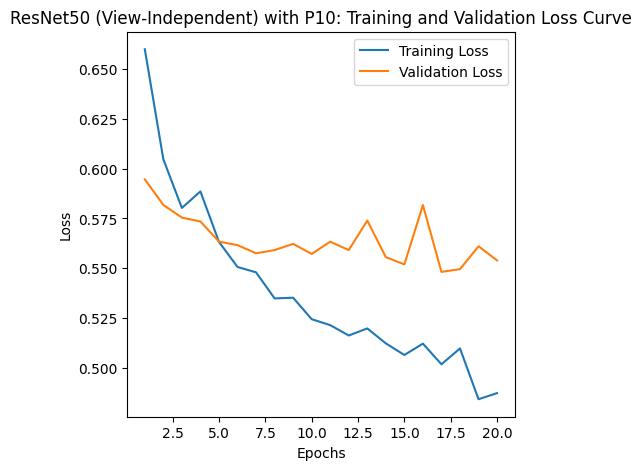

In [ ]:
# Training-Validation Loss curve for P10 pipeline
plot_training_validation_loss(resnet50_p10.history, 'ResNet50 (View-Independent)', 'P10')

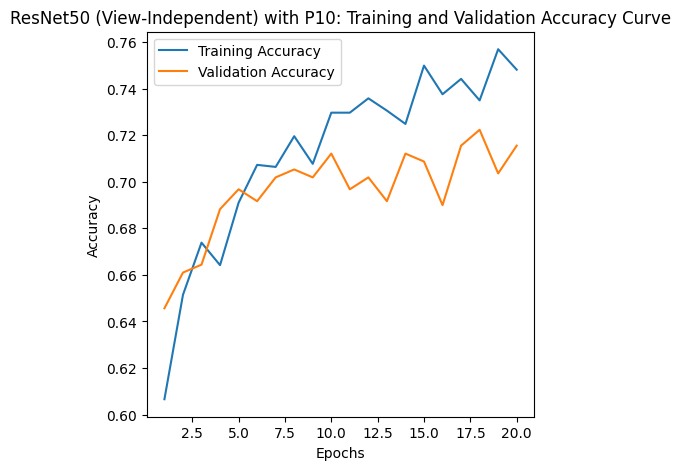

In [ ]:
# Training-Validation Accuracy curve for P10 pipeline
plot_training_validation_accuracy(resnet50_p10.history, 'ResNet50 (View-Independent)', 'P10')

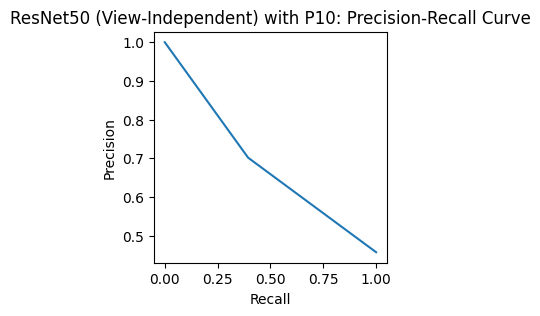

In [ ]:
# Precision-Recall curve for P10 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p10, 'ResNet50 (View-Independent)', 'P10')

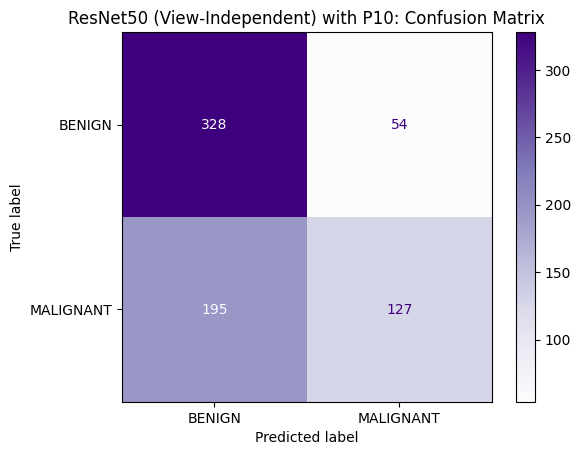

In [ ]:
# Confusion matrix for P10 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p10, 'ResNet50 (View-Independent)', 'P10')